# **Gaussian Filtering for Noise Removal**
---

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Read image in grayscale
img = cv2.imread(r"C:\BDA\digital image processing\Dip_class\dip_img\images_noise.jfif", 0)

In [15]:
# Kernel size and sigma
ksize = 10
sigma = 1.2

In [16]:
# Create Gaussian kernel
def gaussian_kernel(size, sigma):
    ax = np.linspace(-(size//2), size//2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2*sigma**2))
    return kernel / np.sum(kernel)

In [17]:
kernel = gaussian_kernel(ksize, sigma)

In [18]:
# Apply convolution
filtered = cv2.filter2D(img, -1, kernel)

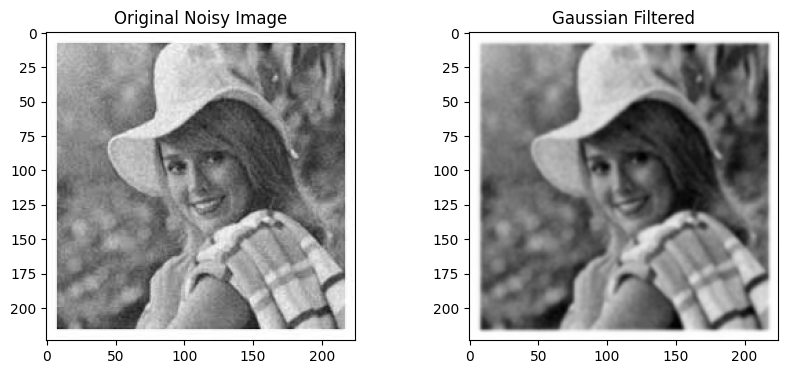

In [19]:
# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original Noisy Image")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Gaussian Filtered")
plt.imshow(filtered, cmap='gray')
plt.show()

In [20]:
# Load grayscale image
img = cv2.imread(r"C:\BDA\digital image processing\Dip_class\dip_img\Noise_color.jfif", 0)

# Add Gaussian Noise
mean = 0
sigma = 25
gaussian_noise = np.random.normal(mean, sigma, img.shape)
noisy_img = img + gaussian_noise
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

In [21]:
def gaussian_kernel(size, sigma):
    k = size // 2
    kernel = np.zeros((size, size), dtype=np.float32)

    for i in range(size):
        for j in range(size):
            x = i - k
            y = j - k
            kernel[i, j] = np.exp(-(x*x + y*y) / (2*sigma*sigma))

    kernel = kernel / np.sum(kernel)
    return kernel

In [22]:
def convolution(image, kernel):
    h, w = image.shape
    k = kernel.shape[0] // 2

    padded = np.pad(image, ((k, k), (k, k)), mode='constant')
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+2*k+1, j:j+2*k+1]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

In [23]:
kernel_size = 7
sigma = 1

kernel = gaussian_kernel(kernel_size, sigma)
filtered_img = convolution(noisy_img, kernel)

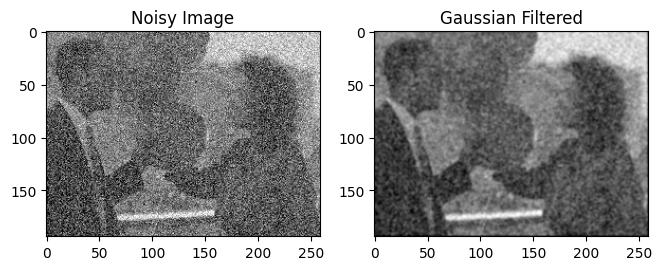

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,2)
plt.title("Noisy Image")
plt.imshow(noisy_img, cmap='gray')

plt.subplot(1,3,3)
plt.title("Gaussian Filtered")
plt.imshow(filtered_img, cmap='gray')

plt.show()